In [106]:
# !pip install imbalanced-learn

In [107]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from imblearn.over_sampling import SMOTE

### Load Dataset

In [108]:
df = pd.read_csv(r'..\Data\spam_detection_dataset.csv')
df.head()

,num_links,num_words,has_offer,sender_score,all_caps,is_spam
0,3,98,1,0.718607,0,0
1,0,170,0,0.698901,1,0
2,0,38,0,0.620466,0,0
3,0,116,0,0.701755,0,0
4,3,89,1,0.583621,1,1


### Data Wrangling and EDA

In [109]:
df.shape

(20000, 6)

In [110]:
#Check for null value
df.isna().sum()

num_links       0
num_words       0
has_offer       0
sender_score    0
all_caps        0
is_spam         0
dtype: int64

In [111]:
#Check for duplicate entires 
df.duplicated().sum()

np.int64(402)

In [112]:
df = df.drop_duplicates()

In [113]:
df.shape

(19598, 6)

In [114]:
df.describe()

,num_links,num_words,has_offer,sender_score,all_caps,is_spam
count,19598.000000,19598.000000,19598.000000,19598.000000,19598.000000,19598.000000
mean,1.503980,109.555771,0.305286,0.687977,0.099347,0.093530
std,1.225113,52.021015,0.460540,0.185019,0.299135,0.291181
min,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,64.000000,0.000000,0.563561,0.000000,0.000000
50%,1.000000,110.000000,0.000000,0.694875,0.000000,0.000000
75%,2.000000,155.000000,1.000000,0.823769,0.000000,0.000000
max,9.000000,199.000000,1.000000,1.000000,1.000000,1.000000


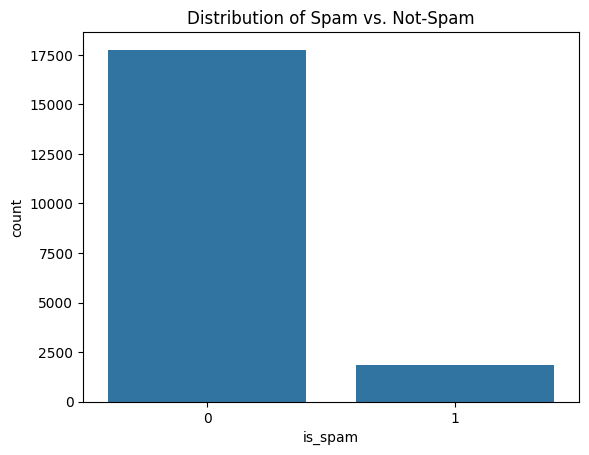

In [115]:
# Distribution of is_spam
sns.countplot(x="is_spam", data=df)
plt.title("Distribution of Spam vs. Not-Spam")
plt.show()

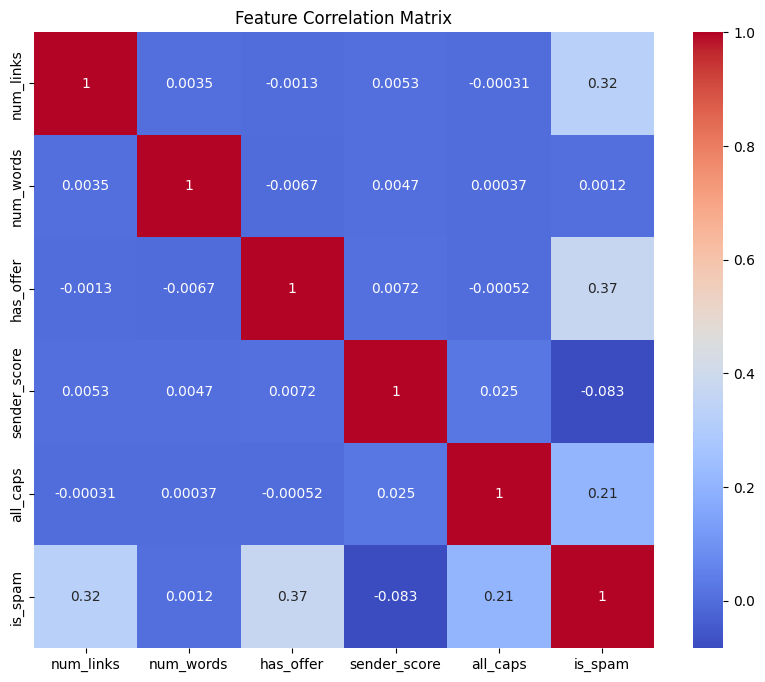

In [116]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

### Data preprocessing

In [117]:
# Separate features and target
X = df.drop('is_spam', axis=1)
y = df['is_spam']

# Split data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

### Implementation of Logistic Regression from Scratch
- `sigmoid()` to map linear predictions to probabilities
- `fit()` to train the model using gradient descent and L2 regularization
- `predict()` to make predictions on new data
- `compute_loss()` to calculate binary cross entropy loss

In [118]:
class CustomLogisticRegression:
    def __init__(self, lr=0.01, n_iterations=1000, lambda_reg=0.01):
        self.lr = lr
        self.n_iters = n_iterations
        self.lambda_reg = lambda_reg
        self.weights = None
        self.bias = None
        self.losses = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def bce_loss(self, y_true, y_pred):
        # binary cross entropy
        epsilon = 1e-9
        y1 = y_true * np.log(y_pred + epsilon)
        y2 = (1 - y_true) * np.log(1 - y_pred + epsilon)
        return -np.mean(y1 + y2)
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iters):
            # Forward pass
            linear_pred = np.dot(X, self.weights) + self.bias
            predictions = self.sigmoid(linear_pred)
            
            # Calculate loss with L2 regularization
            l2_loss = (self.lambda_reg / (2 * n_samples)) * np.sum(self.weights ** 2)
            self.losses.append(self.bce_loss(y, predictions) + l2_loss)
            
            # Compute gradients with L2 regularization
            dw = (1 / n_samples) * (np.dot(X.T, (predictions - y)) + self.lambda_reg * self.weights)
            db = (1 / n_samples) * np.sum(predictions - y)
            
            # Update parameters
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
    
    def predict(self, X):
        linear_pred = np.dot(X, self.weights) + self.bias
        y_pred = self.sigmoid(linear_pred)
        return (y_pred >= 0.5).astype(int)

Classification Report for Custom Logistic Regression:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      3540
           1       0.81      0.12      0.21       380

    accuracy                           0.91      3920
   macro avg       0.86      0.56      0.58      3920
weighted avg       0.90      0.91      0.88      3920



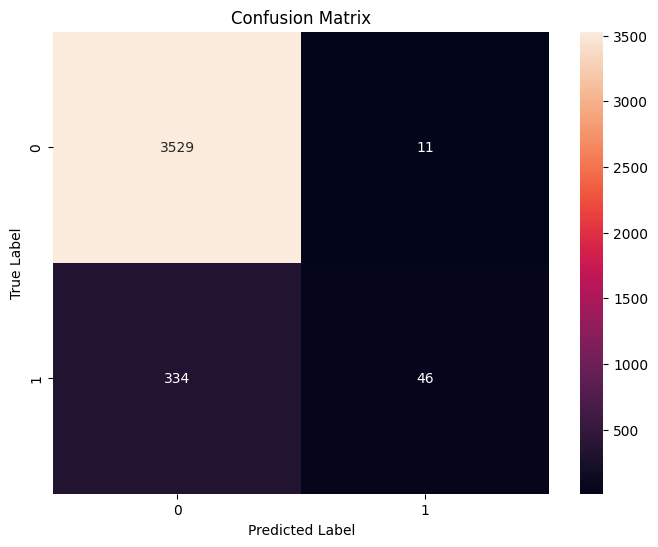

In [119]:
# Train the custom model
custom_model = CustomLogisticRegression(lr=0.01, n_iterations=1000)
custom_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = custom_model.predict(X_val_scaled)

# Print the classification report
print("Classification Report for Custom Logistic Regression:")
print(classification_report(y_val, y_pred))

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

### Visualize Training Loss
Plot the loss curve to check model convergence

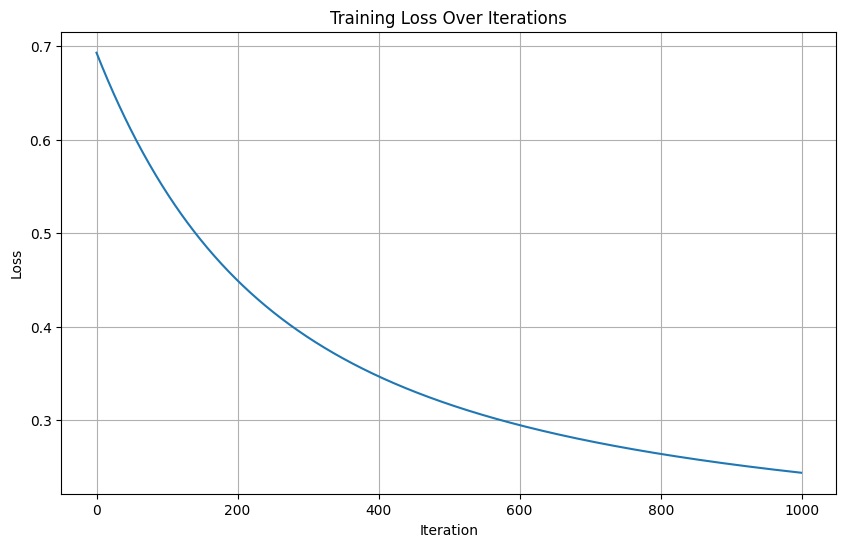

In [120]:
# Plot the training loss
plt.figure(figsize=(10,6))
plt.plot(custom_model.losses)
plt.title('Training Loss Over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

### Train Sklearn Model for Comparison
Train a sklearn logistic regression model and compare results

Classification Report for Sklearn Logistic Regression:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      3540
           1       0.81      0.52      0.63       380

    accuracy                           0.94      3920
   macro avg       0.88      0.76      0.80      3920
weighted avg       0.94      0.94      0.94      3920



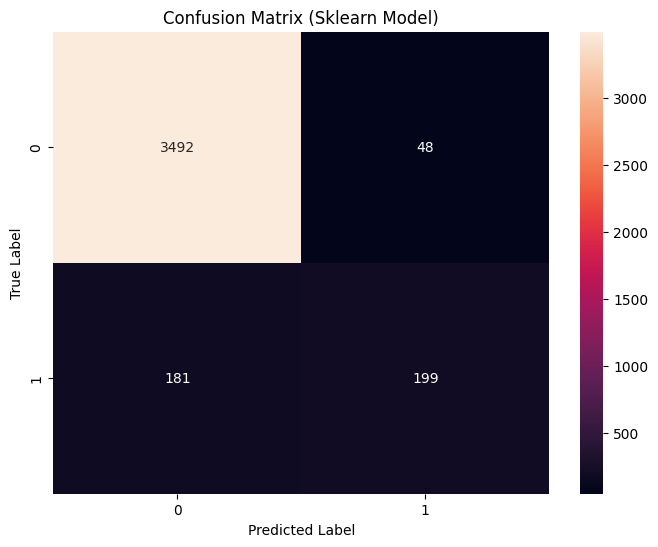

In [121]:
# Train sklearn model
sklearn_model = LogisticRegression(random_state=42, max_iter=1000)
sklearn_model.fit(X_train_scaled, y_train)

# Get predictions
sklearn_preds = sklearn_model.predict(X_val_scaled)
sklearn_probs = sklearn_model.predict_proba(X_val_scaled)[:, 1]

# Print sklearn model results
print("Classification Report for Sklearn Logistic Regression:")
print(classification_report(y_val, sklearn_preds))

# Plot confusion matrix for sklearn model
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_val, sklearn_preds), annot=True, fmt='d')
plt.title('Confusion Matrix (Sklearn Model)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

### Compare ROC Curves
Plot ROC curves for both models to compare their performance

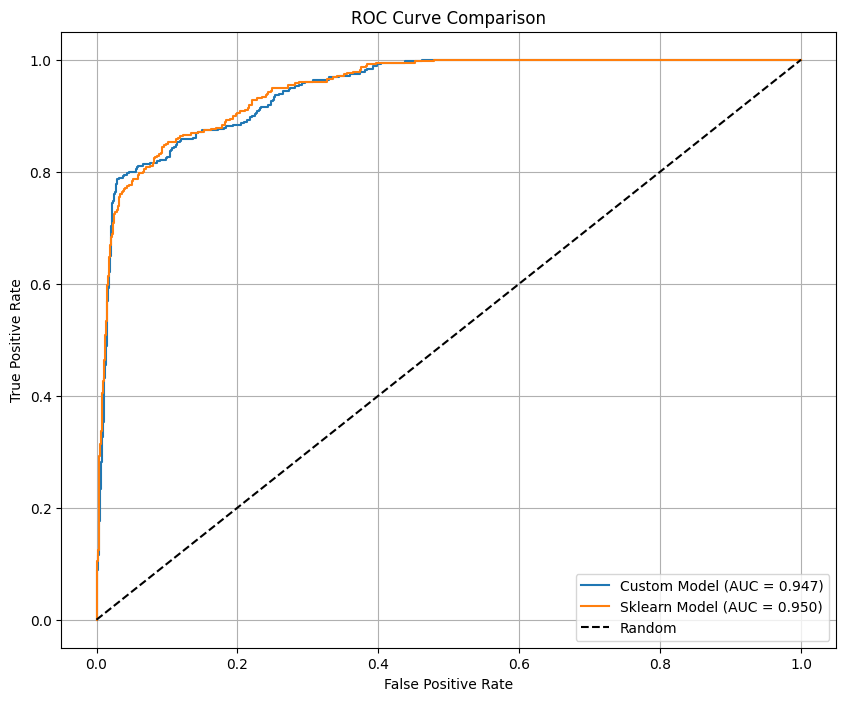

In [122]:
# Calculate ROC curves
custom_probs = custom_model.sigmoid(np.dot(X_val_scaled, custom_model.weights) + custom_model.bias)
fpr_custom, tpr_custom, _ = roc_curve(y_val, custom_probs)
fpr_sklearn, tpr_sklearn, _ = roc_curve(y_val, sklearn_probs)

# Calculate AUC
auc_custom = auc(fpr_custom, tpr_custom)
auc_sklearn = auc(fpr_sklearn, tpr_sklearn)

# Plot ROC curves
plt.figure(figsize=(10,8))
plt.plot(fpr_custom, tpr_custom, label=f'Custom Model (AUC = {auc_custom:.3f})')
plt.plot(fpr_sklearn, tpr_sklearn, label=f'Sklearn Model (AUC = {auc_sklearn:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

### Class Imbalance Analysis

Let's analyze the class distribution and handle any imbalance using SMOTE (Synthetic Minority Over-sampling Technique)

In [123]:
# Check class distribution
print("Class Distribution:")
print(df['is_spam'].value_counts())
print("\nClass Distribution (Percentage):")
print(df['is_spam'].value_counts(normalize=True) * 100)

Class Distribution:
is_spam
0    17765
1     1833
Name: count, dtype: int64

Class Distribution (Percentage):
is_spam
0    90.647005
1     9.352995
Name: proportion, dtype: float64


### Handle Class Imbalance using SMOTE

Original training dataset shape: {np.int64(0): np.int64(14225), np.int64(1): np.int64(1453)}
Balanced training dataset shape: {np.int64(0): np.int64(14225), np.int64(1): np.int64(14225)}


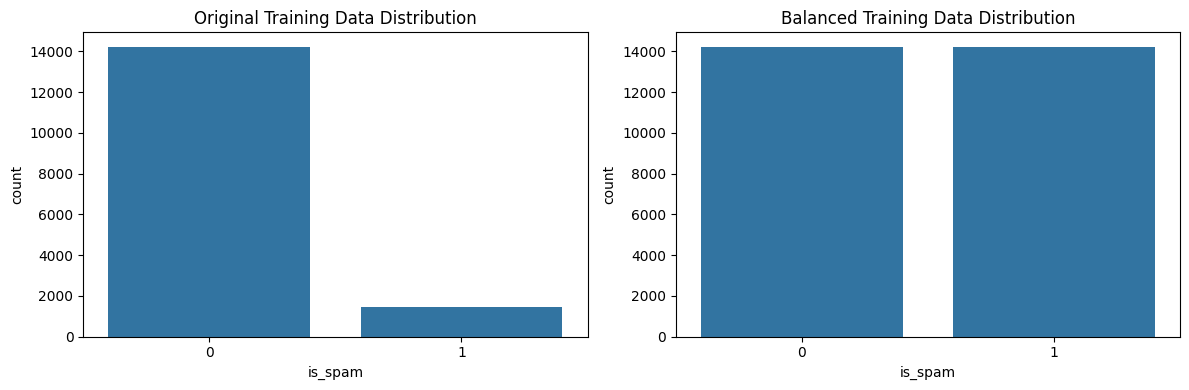

In [124]:
# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE on training data
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print("Original training dataset shape:", dict(zip(np.unique(y_train), np.bincount(y_train))))
print("Balanced training dataset shape:", dict(zip(np.unique(y_train_balanced), np.bincount(y_train_balanced))))

# Visualize class distribution after SMOTE
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.countplot(x=y_train)
plt.title("Original Training Data Distribution")

plt.subplot(1, 2, 2)
sns.countplot(x=y_train_balanced)
plt.title("Balanced Training Data Distribution")
plt.tight_layout()
plt.show()

### Train Models on Balanced Data

Let's train both custom and sklearn models on the balanced dataset

Classification Report for Custom Logistic Regression (Balanced Data):
              precision    recall  f1-score   support

           0       0.99      0.77      0.87      3540
           1       0.30      0.93      0.46       380

    accuracy                           0.78      3920
   macro avg       0.65      0.85      0.66      3920
weighted avg       0.92      0.78      0.83      3920



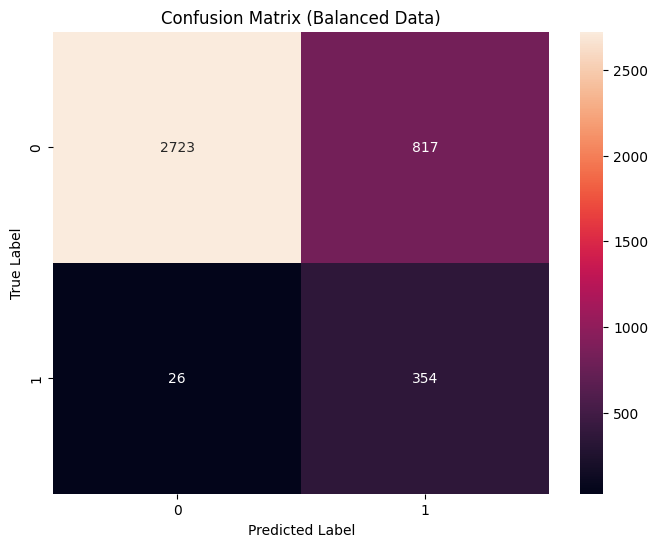

In [125]:
# Train custom model on balanced data
custom_model_balanced = CustomLogisticRegression(lr=0.01, n_iterations=1000, lambda_reg=0.01)
custom_model_balanced.fit(X_train_balanced, y_train_balanced)

# Make predictions
y_pred_balanced = custom_model_balanced.predict(X_val_scaled)

# Print classification report
print("Classification Report for Custom Logistic Regression (Balanced Data):")
print(classification_report(y_val, y_pred_balanced))

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_val, y_pred_balanced), annot=True, fmt='d')
plt.title('Confusion Matrix (Balanced Data)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Classification Report for Sklearn Logistic Regression (Balanced Data):
              precision    recall  f1-score   support

           0       0.99      0.86      0.92      3540
           1       0.41      0.88      0.56       380

    accuracy                           0.86      3920
   macro avg       0.70      0.87      0.74      3920
weighted avg       0.93      0.86      0.88      3920



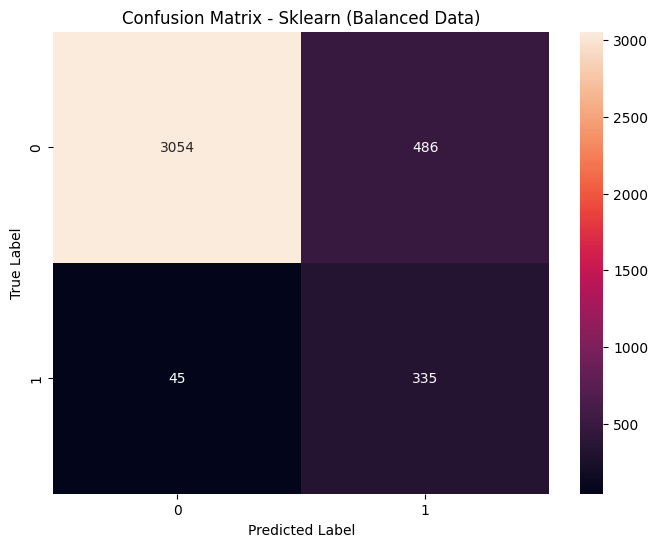

In [126]:
# Train sklearn model on balanced data
sklearn_model_balanced = LogisticRegression(random_state=42, max_iter=1000)
sklearn_model_balanced.fit(X_train_balanced, y_train_balanced)

# Get predictions
sklearn_preds_balanced = sklearn_model_balanced.predict(X_val_scaled)
sklearn_probs_balanced = sklearn_model_balanced.predict_proba(X_val_scaled)[:, 1]

# Print classification report
print("Classification Report for Sklearn Logistic Regression (Balanced Data):")
print(classification_report(y_val, sklearn_preds_balanced))

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_val, sklearn_preds_balanced), annot=True, fmt='d')
plt.title('Confusion Matrix - Sklearn (Balanced Data)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

### Compare ROC Curves with Balanced Data

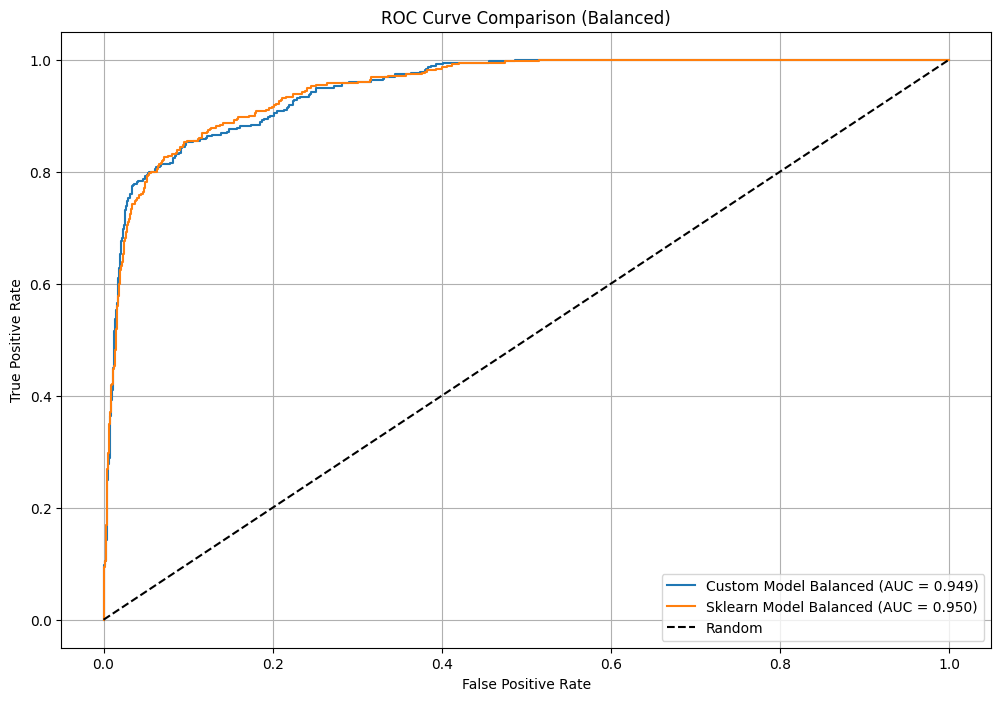

In [127]:
# Calculate ROC curves for balanced models
custom_probs_balanced = custom_model_balanced.sigmoid(np.dot(X_val_scaled, custom_model_balanced.weights) + custom_model_balanced.bias)
fpr_custom_balanced, tpr_custom_balanced, _ = roc_curve(y_val, custom_probs_balanced)
fpr_sklearn_balanced, tpr_sklearn_balanced, _ = roc_curve(y_val, sklearn_probs_balanced)

# Calculate AUC
auc_custom_balanced = auc(fpr_custom_balanced, tpr_custom_balanced)
auc_sklearn_balanced = auc(fpr_sklearn_balanced, tpr_sklearn_balanced)

# Plot ROC curves
plt.figure(figsize=(12,8))
plt.plot(fpr_custom_balanced, tpr_custom_balanced, 
         label=f'Custom Model Balanced (AUC = {auc_custom_balanced:.3f})')
plt.plot(fpr_sklearn_balanced, tpr_sklearn_balanced, 
         label=f'Sklearn Model Balanced (AUC = {auc_sklearn_balanced:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (Balanced)')
plt.legend()
plt.grid(True)
plt.show()

### Why is Accuracy Not Suitable for All Cases?

Accuracy is not always a suitable metric, especially in cases of imbalanced datasets like our spam detection problem. Here's why:

1. **Class Imbalance Issue**:
   - In our dataset, looking at the class distribution, we have an imbalanced dataset with more non-spam than spam emails
   - With imbalanced data, a model could achieve high accuracy simply by predicting the majority class
   - For example, if 90% of emails are non-spam, a model could achieve 90% accuracy by always predicting "non-spam"

2. **Misleading Results**:
   - Our initial model showed high accuracy but may not be equally good at detecting both spam and non-spam
   - Looking at the confusion matrix, we can see differences in performance between classes
   - The balanced accuracy or F1 score gives a better picture of model performance

3. **Cost of Errors**:
   - Accuracy treats all errors equally
   - In spam detection, falsely marking a legitimate email as spam (False Positive) might be more costly than missing a spam email
   - This is why we need metrics like precision and recall

4. **Real-world Impact**:
   - After applying SMOTE, we see changes in model performance that weren't reflected in accuracy alone
   - The balanced model might have lower accuracy but better performance on the minority class

### When to Choose Precision over Recall and Vice-versa?

Understanding when to prioritize precision or recall depends on the specific goals and consequences of errors in our application.

#### Precision (When False Positives are Costly):
- Choose precision when it’s more important that the positive predictions are correct.
- Example: Diagnosing a rare but serious disease  
  - If a test says someone has the disease, you want to be *very sure* it's true - false positives could lead to unnecessary stress, further testing, or treatment.
- In such cases, it's better to reduce the number of false positives, even if that means missing some actual cases.


#### Recall (When False Negatives are Costly):
- Choose recall when it’s crucial to identify as many actual positive cases as possible.
- Example: Airport security screening for prohibited items
  - Missing a true threat (a false negative) could have severe consequences, so the system should flag as many potential threats as possible - even if that means occasionally flagging harmless items.
- Here, it’s acceptable to have some false positives to avoid missing any true threats.


#### Trade-off Illustration:

1. High Precision, Low Recall:
2. High Recall, Low Precision: